# TP : Variational autoencoder

In this practical session, our objective is to implement and to train from scratch a variational auto-encoder to produce images of digits using the dataset MNIST.

## 1: MNIST Dataset

The script below loads the training images and the test images of MNIST dataset.

In [1]:
import torch
from torch import nn, optim
import torch.nn.functional as F
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
tensor_transform = transforms.ToTensor()
dataset_train = datasets.MNIST(root="./data", train=True, download=True, transform=tensor_transform)
dataset_test = datasets.MNIST(root="./data", train=False, download=True, transform=tensor_transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 505kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.67MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.1MB/s]


Let us display some training images.

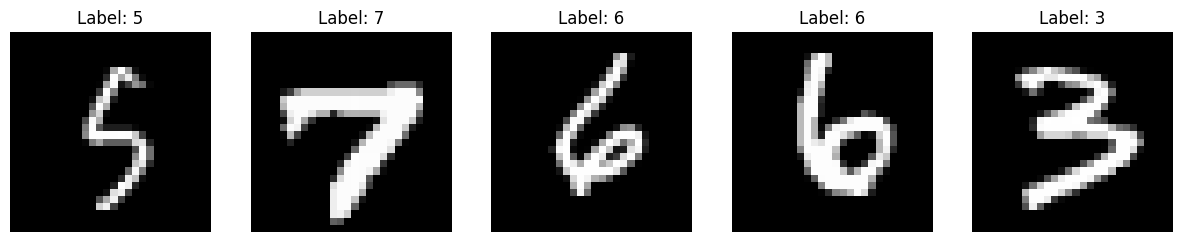

In [3]:
trainloader = torch.utils.data.DataLoader(dataset=dataset_train, batch_size=32, shuffle=True)
images, labels = next(iter(trainloader))
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis('off')
plt.show()

## 2: Auto-encoder model

We start by implementing an auto-encoder for learning a compressed representation of each image of the dataset.

**Question 1**: Using the template class AutoEncoder, implement an autoencoder architecture compressing the 28x28 MNIST images into a 9-dimensional latent space and reconstruct them. The encoder uses fully connected layers with ReLU activations for hidden layers and reduce the dimension in the following way : 28 x 28 = 784 -> 128 -> 64 -> 36 -> 18 -> 9. The decoder mirrors the encoder architecture. Its final layer uses a sigmoid non-linearity.

In [10]:
class AutoEncoder(nn.Module):
    
    """
    Autoencoder for MNIST digit reconstruction.

    This model compresses 28x28 MNIST images into a 9-dimensional latent space
    and reconstructs them. The architecture uses fully connected layers with ReLU
    activations for hidden layers and Sigmoid for the output layer.

    Attributes:
        encoder (nn.Sequential): Encoder network to compress input images.
        decoder (nn.Sequential): Decoder network to reconstruct images from latent space.
    """

    def __init__(self):
        super().__init__()
        
        """
        Initializes the autoencoder with encoder and decoder networks
        """
        # TODO: Complete code
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(), 
            nn.Linear(128, 64), 
            nn.ReLU(), 
            nn.Linear(64, 36),
            nn.ReLU(), 
            nn.Linear(36, 9),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(9, 36),
            nn.ReLU(),
            nn.Linear(36, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        
        """
        Forward pass of the autoencoder.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, 784).

        Returns:
            torch.Tensor: Reconstructed image tensor of shape (batch_size, 784).
        """
        # TODO: Complete code
        z = self.encoder(x)
        decoded = self.decoder(z)
        return decoded

### Training the model

**Question 2**: complete the following script to train the model.

In [ ]:
ae = AutoEncoder()
loss_function = nn.MSELoss()

optimizer = optim.Adam(ae.parameters(), lr=1e-3, weight_decay=1e-8)

In [ ]:
epochs = 20
outputs = []
losses = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ae = ae.to(device)

# TODO: Complete code
for epoch in range(epochs): 
    for images, labels in trainloader:
        images = images.to(device)

        vectors = images.reshape(-1, 784)

        optimizer.zero_grad()
        reconstruction = ae(vectors)
        loss = loss_function(vectors, reconstruction)
        losses.append(loss)

        loss.backward()

        optimizer.step()

        
    print("epoch terminé : ", epoch)
        


epoch terminé :  0
epoch terminé :  1
epoch terminé :  2
epoch terminé :  3
epoch terminé :  4
epoch terminé :  5
epoch terminé :  6
epoch terminé :  7
epoch terminé :  8
epoch terminé :  9
epoch terminé :  10
epoch terminé :  11
epoch terminé :  12
epoch terminé :  13
epoch terminé :  14
epoch terminé :  15
epoch terminé :  16
epoch terminé :  17
epoch terminé :  18
epoch terminé :  19


In [31]:
print(losses[0][0])

[[...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...], [...]

KeyboardInterrupt: 

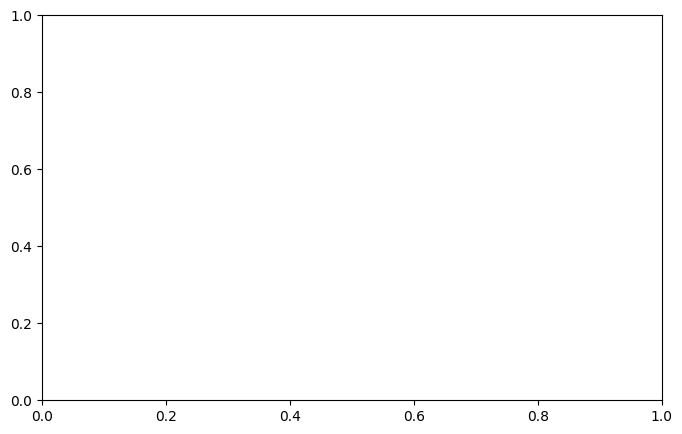

KeyboardInterrupt: 

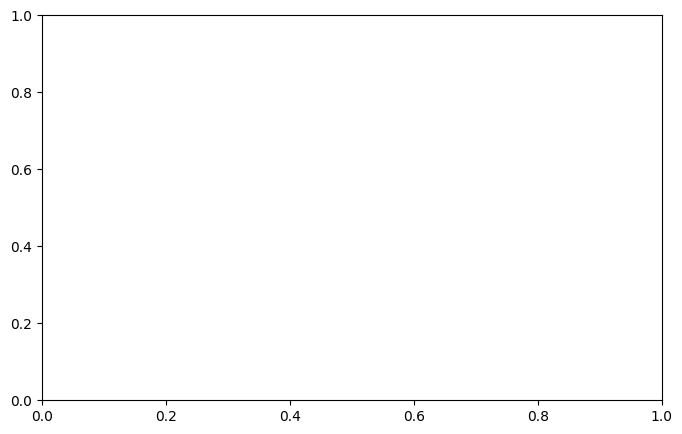

KeyboardInterrupt: 

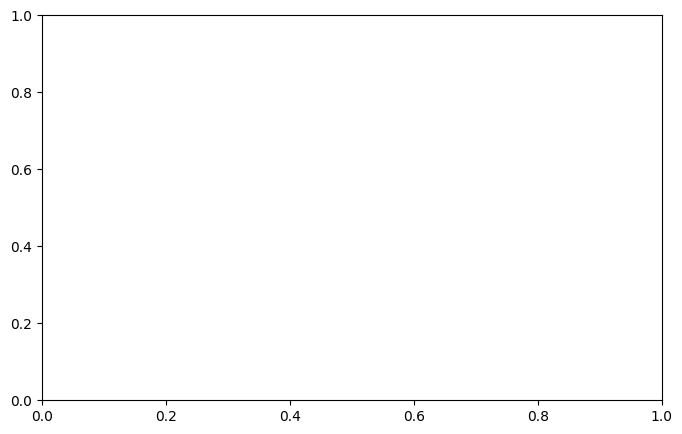

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(losses[0:100], label='Loss')
plt.xlabel('bacth')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Testing the model

The following script checks if the auto-encoder performs the reconstruction properly.

torch.Size([32, 784])


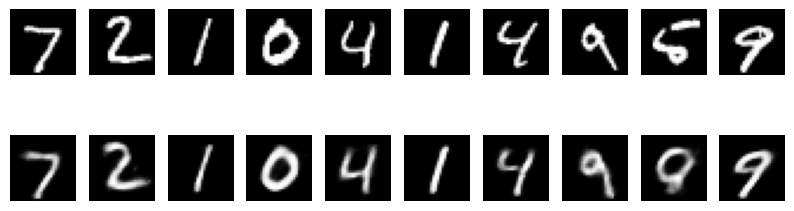

In [36]:
ae.eval()
testloader = torch.utils.data.DataLoader(dataset=dataset_test, batch_size=32, shuffle=False)
dataiter = iter(testloader)
images, _ = next(dataiter)

images = images.view(-1, 28 * 28).to(device)
print(ae(images).shape)
reconstructed = ae(images)


fig, axes = plt.subplots(nrows=2, ncols=10, figsize=(10, 3))
for i in range(10):
    axes[0, i].imshow(images[i].cpu().detach().numpy().reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[i].cpu().detach().numpy().reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
plt.show()

## 3: Variational Auto-encoder

We can now start with the implementation of the variational auto-encoder. The encoder uses fully connected layers with ReLU activations for the hidden layers and reduce the dimension in the following way : 28 x 28 = 784 -> 128 -> 64 -> 36. The final layer of the encoder predicts the mean (dim=9) and the log-variance (dim=9) of the distribution of the latent variable. The decoder mirrors the encoder architecture. Its final layer uses a sigmoid non-linearity.

**Question 3**: Complete the implementation of the VAE using the template of the class VAE.

In [ ]:
class VAE(nn.Module):
    
    """
    Variational Autoencoder (VAE) for MNIST digit reconstruction.
    This model compresses 28x28 MNIST images into a 9-dimensional latent space,
    using a probabilistic approach to generate new samples.
    Attributes:
        encoder (nn.Sequential): Encoder network to output mean and log-variance of latent distribution.
        decoder (nn.Sequential): Decoder network to reconstruct images from latent space.
        latent_dim (int): Dimensionality of the latent space.
    """

    def __init__(self, latent_dim=9):
        """
        Initializes the VAE with encoder and decoder networks.
        Args:
            latent_dim (int): Dimensionality of the latent space.
        """
        # TODO: Complete code
        self.encoder = nn.Sequential(
                nn.Linear(784, 128),
                nn.ReLU(), 
                nn.Linear(128, 64), 
                nn.ReLU(), 
                nn.Linear(64, 36),
                nn.ReLU(), 
                nn.Linear(36, 18),
                nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(9, 36),
            nn.ReLU(),
            nn.Linear(36, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def encode(self, x: torch.Tensor):
        """
        Encodes the input into mean and log-variance of the latent distribution
        
        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, 784)
            
        Returns:
            tuple: (mu, log_var), each of shape (batch_size, latent_dim)
        """
        # TODO: Complete code
        z = self.encoder(x)
        mu = z[:,0:9]
        log_var = z[:,9:18]
        return (mu, log_var)

    def reparameterize(self, mu, log_var):
        """
        Reparameterization trick to sample from N(mu, var)
        
        Args:
            mu (torch.Tensor): Mean of the latent distribution
            log_var (torch.Tensor): Log-variance of the latent distribution
            
        Returns:
            torch.Tensor: Sampled latent vector of shape (batch_size, latent_dim)
        """
        u = torch.randn_like(mu)*torch.exp(log_var/2) + mu 
        return u 


        # TODO: Complete code

    def decode(self, z):
        """
        Decodes the latent vector into a reconstructed image
        
        Args:
            z (torch.Tensor): Latent vector of shape (batch_size, latent_dim)
            
        Returns:
            torch.Tensor: Reconstructed image tensor of shape (batch_size, 784)
        """
        # TODO: Complete code

    def forward(self, x):
        """
        Forward pass of the VAE
        
        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, 784)
            
        Returns:
            tuple: (reconstructed image, mean, log-variance)
        """
        # TODO: Complete code
        

def vae_loss(recon_x, x, mu, log_var):
    
    """
    Computes the VAE loss (reconstruction loss + KL divergence)
    
    Args:
        recon_x (torch.Tensor): Reconstructed image tensor
        x (torch.Tensor): Original input tensor
        mu (torch.Tensor): Mean of the latent distribution
        log_var (torch.Tensor): Log-variance of the latent distribution
        
    Returns:
        torch.Tensor: Total loss (reconstruction loss + KL divergence)
    """
    
    # Reconstruction loss (binary cross-entropy)
    MSE = F.mse_loss(recon_x, x, reduction='sum')
    
    # KL divergence
    KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return MSE + KLD

## Training the VAE

In [31]:
vae = VAE(latent_dim=9)
optimizer = optim.Adam(vae.parameters(), lr=0.001)

epochs = 30
outputs = []
losses = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae.to(device)

for epoch in range(epochs):
    for images, _ in trainloader:
        images = images.view(-1, 28 * 28).to(device)

        # Forward pass
        recon_images, mu, log_var = vae(images)
        loss = vae_loss(recon_images, images, mu, log_var)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    outputs.append((epoch, images, reconstructed))
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")
    

Epoch 1/30, Loss: 1471.877930
Epoch 2/30, Loss: 1356.046753
Epoch 3/30, Loss: 1229.743408
Epoch 4/30, Loss: 1207.348145
Epoch 5/30, Loss: 1209.681274
Epoch 6/30, Loss: 1250.878418
Epoch 7/30, Loss: 1163.952148
Epoch 8/30, Loss: 1214.167236
Epoch 9/30, Loss: 1203.912842
Epoch 10/30, Loss: 1296.282349
Epoch 11/30, Loss: 1136.522217
Epoch 12/30, Loss: 1125.400269
Epoch 13/30, Loss: 1184.603760
Epoch 14/30, Loss: 1191.251953
Epoch 15/30, Loss: 1165.341797
Epoch 16/30, Loss: 1017.664917
Epoch 17/30, Loss: 1106.833496
Epoch 18/30, Loss: 1168.963379
Epoch 19/30, Loss: 1061.702881
Epoch 20/30, Loss: 1155.578369
Epoch 21/30, Loss: 1059.875366
Epoch 22/30, Loss: 1081.573975
Epoch 23/30, Loss: 1150.628296
Epoch 24/30, Loss: 993.666199
Epoch 25/30, Loss: 1014.171387
Epoch 26/30, Loss: 1089.749634
Epoch 27/30, Loss: 1172.404175
Epoch 28/30, Loss: 1159.717285
Epoch 29/30, Loss: 970.906738
Epoch 30/30, Loss: 917.838928


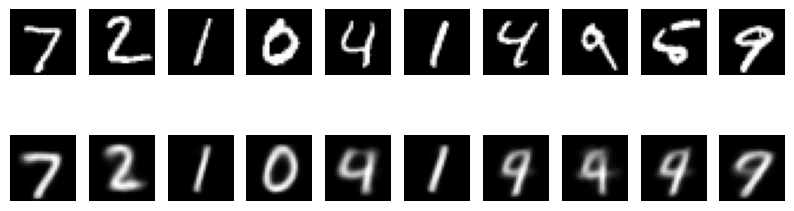

In [32]:
vae.eval()
dataiter = iter(testloader)
images, _ = next(dataiter)

images = images.view(-1, 28 * 28).to(device)
reconstructed, _, _ = vae(images)

fig, axes = plt.subplots(nrows=2, ncols=10, figsize=(10, 3))
for i in range(10):
    axes[0, i].imshow(images[i].cpu().detach().numpy().reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[i].cpu().detach().numpy().reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
plt.show()

## 4. Interpolation in the latent space

Here, our goal is to leverage autoencoder (AE) and variational autoencoder (VAE) architectures to perform image interpolation. Unlike traditional pixel-based interpolation methods—which often produce blurry or unrealistic transitions—our approach focuses on interpolating directly in the latent space. This method preserves the semantic structure of the data, ensuring that the generated intermediate images remain meaningful and coherent. The use of VAEs adds a probabilistic framework, ensuring that the latent space is well-structured and that interpolations remain within the distribution of the training data.

The following method interpolates between two images directly in the pixels space.

In [34]:
def interpolate_in_image_space(img1, img2, num_steps=10):
    
    """
    Interpolates between two images in pixel space.

    Args:
        img1 (torch.Tensor): First image tensor (shape: [1, 28, 28] or [28, 28]).
        img2 (torch.Tensor): Second image tensor (shape: [1, 28, 28] or [28, 28]).
        num_steps (int): Number of interpolation steps.
    Returns:
        list: Interpolated images as tensors.
    """
    interpolated_images = []
    for alpha in torch.linspace(0, 1, num_steps):
        # Linear interpolation: img1 + alpha * (img2 - img1)
        interpolated_img = img1 + alpha * (img2 - img1)
        interpolated_images.append(interpolated_img)
    return interpolated_images

**Question 4**: Complete the implementation of the two following functions for performing the interpolation in the latent space of the VAE and of the autoencoder

In [35]:
def interpolate_with_vae(vae, img1, img2, num_steps=10):
    
    """
    Interpolates between two images in the latent space.

    Args:
        vae (VAE): Trained VAE model.
        img1 (torch.Tensor): First image tensor (flattened).
        img2 (torch.Tensor): Second image tensor (flattened).
        num_steps (int): Number of interpolation steps.
    Returns:
        list: Interpolated images as tensors.
    """
    # TODO: Complete code


In [36]:
def interpolate_with_ae(ae, img1, img2, num_steps=10):
    
    """
    Interpolates between two images in the latent space with an auto-encoder.

    Args:
        ae (AE): Trained AE model.
        img1 (torch.Tensor): First image tensor (flattened).
        img2 (torch.Tensor): Second image tensor (flattened).
        num_steps (int): Number of interpolation steps.
    Returns:
        list: Interpolated images as tensors.
    """
    # TODO: Complete code

The following script interpolates between two images selected randomly from the test dataset

In [52]:
random_indices = torch.randperm(len(dataset_test))[:2]
img1, _ = dataset_test[random_indices[0]]
img2, _ = dataset_test[random_indices[1]]
interpolated_images = interpolate_in_image_space(img1, img2, num_steps=10)
interpolated_vae = interpolate_with_vae(vae, img1, img2, num_steps=10)
interpolated_ae = interpolate_with_ae(ae, img1, img2, num_steps=10)

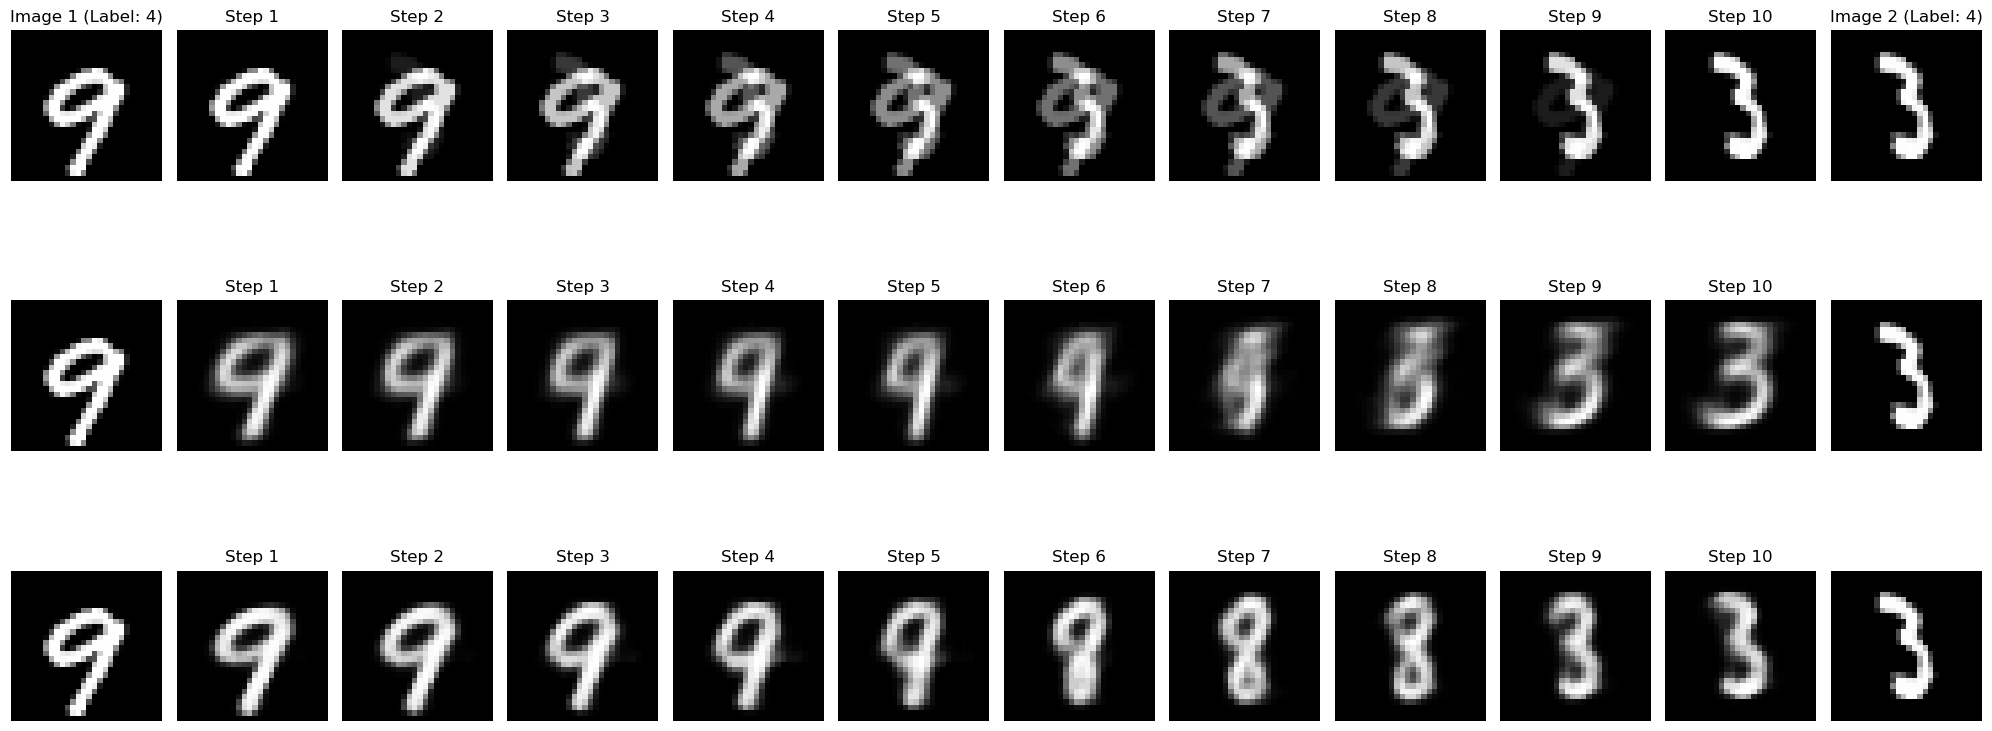

In [53]:
num_steps = len(interpolated_images)
fig, axes = plt.subplots(3, num_steps + 2, figsize=(20, 9))

# Plot original images in all rows
for row in range(3):
    axes[row, 0].imshow(img1.cpu().numpy().reshape(28, 28), cmap='gray')
    axes[row, 0].set_title(f'Image 1 (Label: {target_label})' if row == 0 else '')
    axes[row, 0].axis('off')
    axes[row, -1].imshow(img2.cpu().numpy().reshape(28, 28), cmap='gray')
    axes[row, -1].set_title(f'Image 2 (Label: {target_label})' if row == 0 else '')
    axes[row, -1].axis('off')

# Plot image space interpolation (first row)
for i, img in enumerate(interpolated_images):
    axes[0, i+1].imshow(img.numpy().reshape(28, 28), cmap='gray')
    axes[0, i+1].set_title(f'Step {i+1}')
    axes[0, i+1].axis('off')

# Plot VAE interpolation (second row)
for i, img in enumerate(interpolated_vae):
    axes[1, i+1].imshow(img.numpy().reshape(28, 28), cmap='gray')
    axes[1, i+1].set_title(f'Step {i+1}')
    axes[1, i+1].axis('off')

# Plot AE interpolation (third row)
for i, img in enumerate(interpolated_ae):
    axes[2, i+1].imshow(img.numpy().reshape(28, 28), cmap='gray')
    axes[2, i+1].set_title(f'Step {i+1}')
    axes[2, i+1].axis('off')
    # Add row labels
    axes[0, 0].set_ylabel('Image Space', fontsize=12)
    axes[1, 0].set_ylabel('VAE', fontsize=12)
    axes[2, 0].set_ylabel('AE', fontsize=12)

plt.tight_layout()
plt.show()